In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pimcs import jspin, destroy, Dicke, rotated_qubits, mcsolve

# setup system in exactly same way as with qutip.piqs
N = 200
OmegaC = 0
OmegaA = 0.1/2
Coupling = 0.1 / np.sqrt(N)

a = destroy(2*N+1) # cavity truncation limit (match number of spins)

Jz = jspin(N, 'z')
Jp = jspin(N, '+')
Jm = jspin(N, '-')

# Tavis-Cummings model
H = OmegaC * a.dag()*a + OmegaA * 2*Jz + Coupling * (Jm * a.dag() + Jp * a)

F_pump = 10
sigma = 20
t_0 = 150
factor = F_pump / np.sqrt(2 * np.pi * sigma**2)

def gaussian_pulse(t):
    return factor * np.exp(-(t - t_0)**2 / (2 * sigma**2))

# add coherent pump
H += gaussian_pulse * (Jp + Jm)

# construct system in the same way, now with cavity loss for (a),
# cavity_emission for (a†σ-) and cavity_absorption for (aσ+)
system = Dicke(N, H, cavity_loss = 0.01, dephasing = 0.01)

# construct initial state, can use dicke(j,m), ground(N), exicted(N)
# or rotated_qubits(N, θ) for (tensorproduct)_i  exp(-i θ/2 σx) |up>_i
psi0 = rotated_qubits(N, 0.1 * np.pi)
times = np.linspace(0, 256, 300)

# similar interface to qutip.mcsolve
# IMPORTANT: a low number of trajectories (~25) is usually sufficient for large N (faster convergence)

data = mcsolve(
    system,
    psi0,               # initial state of simulations
    times,              # times to output expecation values (must be linearly spaced for now)
    [a.dag()*a, Jz],    # operators of expectation values to output
    ntraj = 100,        # number of Monte Carlo simulations to run 
    ncpu = 8,           # number of simulations to run in parallel (ideally = number of CPU cores)
    
    # optional arguments (default values shown)
    jtol = 0.05,        # parameter to tune integration step size (lower is more accurate but slower)
    stol = 1e-20,       # tolerance of probability density to shrink Hilbert space to
    rkpoly = 4,         # Runge Kutta order for integrating effective Hamiltonian
)

Building optimized executable...
Running trajectories...


Trajectory [100/100] completed, average time: 1.737 seconds.


HERE!!!!


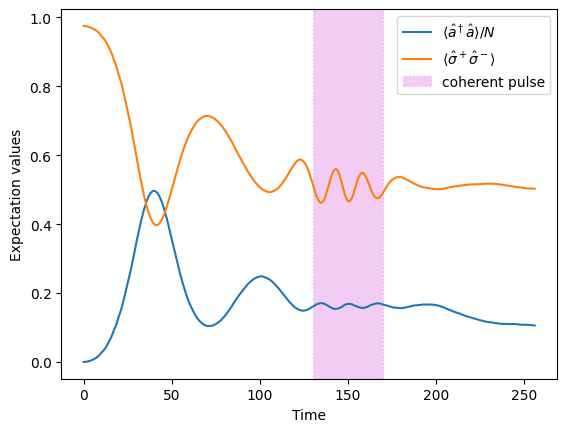

In [2]:
## N =  up + down
# M = (up - down)/2
# up = N/2 + M

photon = data.expect[0]
spin_up = N/2 + data.expect[1]

plt.plot(times, photon / N, label = "$\\langle \\hat{a}^\\dagger \\hat{a} \\rangle / N$")
plt.plot(times, spin_up / N, label = "$\\langle \\hat{\\sigma}^+ \\hat{\\sigma}^- \\rangle$")
plt.axvspan(t_0 - sigma, t_0 + sigma, color = 'm', alpha = 0.2, ls = ':', label = "coherent pulse")

plt.xlabel("Time")
plt.ylabel("Expectation values")
plt.legend();

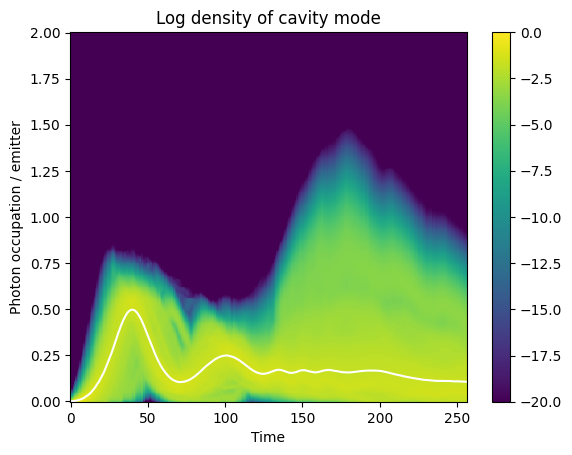

In [3]:
plt.pcolormesh(times, np.arange(2*N+1) / N, np.log10(data.boson_density + 1e-20))
plt.plot(times, photon / N, c = 'white', ls = '-')
plt.colorbar()

plt.title("Log density of cavity mode")
plt.xlabel("Time")
plt.ylabel("Photon occupation / emitter");

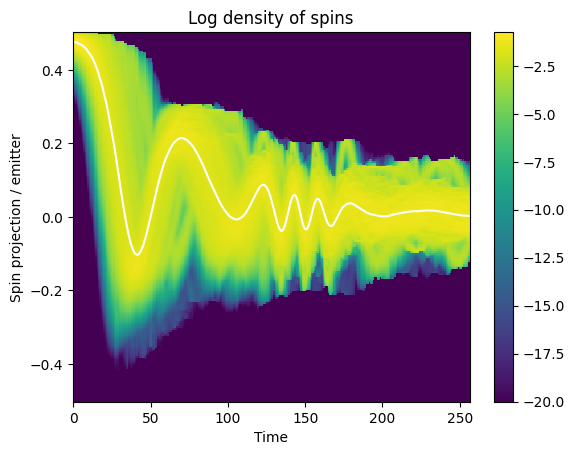

In [4]:
M = N/2 - np.arange(N+1)

plt.pcolormesh(times, M / N, np.log10(data.spin_density + 1e-20))
plt.plot(times, spin_up / N - 0.5, c = 'white')
plt.colorbar()

plt.title("Log density of spins")
plt.xlabel("Time")
plt.ylabel("Spin projection / emitter");